<a href="https://colab.research.google.com/github/ejlim6181three-rgb/Eco6181/blob/main/%EC%A7%80%EB%8A%A5%ED%98%95%EA%B2%8C%EC%9E%84_%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

문제 1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.

intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미

extrinsic 파라미터 (R, t)의 역할

이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

P=K[R∣t]행렬은 3d 점을 카메라 이미지의 2d 픽셀 좌표로 바꾸는 행렬이라는 의미를 가지고 있다.


*   intrinsic 파라미터 f_x, f_y는 x와 y의 초점거리를, c_x, c_y는 이미지 중심점을 의미한다.
* extrinsic 파라미터(R,T)에서 R은 좌표계를 회전시키고 t는 이동시켜서 차량 좌표계의 점을 카메라 좌표계로 바꾸는 역할이다.

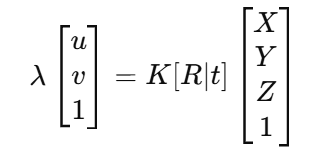

투영행렬 코드에서 λ는 카메라 좌표계에서 깊이를 의미하는데, 마지막에 깊이 λ로 나눠서 Z값이 1이 되는 평면, 즉 카메라 원점에서 Z축 방향으로 1만큼 떨어진 가상의 평면에 투영시켜서 이미지 좌표(2d 좌표)로 변환시킨다.



문제 2. Projection Matrix를 이용한 3D → 2D 투영

임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.

투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오.

Z가 클수록 점들이 소실점 방향으로 모이면서 Z=20 점들이 Z=10보다 더 가운데 몰려있는 원근 수렴현상이 나타난다.
멀수록 X,Y 간격이 좁아져서 점 간격이 줄어드는 카메라 투명 특성과 일치한다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


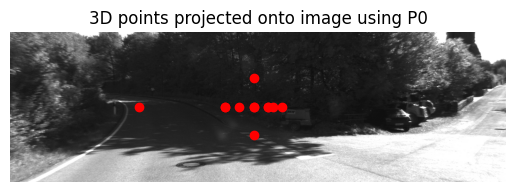

In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

calib = pd.read_csv(
    '/content/drive/MyDrive/dataset/sequences/09/calib.txt',
    delimiter=' ',
    header=None,
    index_col=0
)

P0 = np.array(calib.loc['P0:']).reshape((3, 4))

points_3d = np.array([
    [0, 0, 10, 1],
    [1, 0, 10, 1],
    [-1, 0, 10, 1],
    [0, 1, 10, 1],
    [0, -1, 10, 1],
    [1, 0, 20, 1],
    [-1, 0, 20, 1],
    [-2, 0, 5, 1],
    [-1, 0, 10, 1],
    [0, 0, 15, 1],
    [1, 0, 20, 1],
    [2, 0, 30, 1],
])

projected = P0 @ points_3d.T
projected = projected / projected[2]

u = projected[0]
v = projected[1]

img = cv2.imread('/content/drive/MyDrive/dataset/sequences/09/image_0/000000.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.scatter(u, v, c='red')
plt.title('3D points projected onto image using P0')
plt.axis('off')
plt.show()

문제 3. Pose를 이용한 차량 궤적 시각화

KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.

각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
초기 프레임을 기준 좌표계로 설정
차량의 이동 방향과 속도에 대해 간단히 설명

차량은 전체적으로 Z축 방향, 즉 전방으로 이동하면서 일부 구간에서는 x축 방향으로 좌우 곡선을 그리며 이동하는 모습을 보인다.
속도 변화의 경우, 궤적에서 점 간격이 일정하지 않고 구간별로 변화하는 것을 통해 속도가 일정하지 않음을 알 수 있다. 특히, 곡선 구간에서 이동방향이 변화하면서 속도도 감소하는 변화가 있고, 직선 구간에서는 비교적 일정한 속도로 이동하고 있다.

In [ ]:
import pandas as pd

poses = pd.read_csv('/content/drive/MyDrive/dataset/poses/09.txt', delimiter=' ', header=None)
print('Data shape:', poses.shape)
poses.head()

Data shape: (1591, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.000000,1.197625e-11,1.704638e-10,5.551115e-17,1.197625e-11,1.000000,3.562503e-10,0.000000,1.704638e-10,3.562503e-10,1.000000,2.220446e-16
1,0.999927,-3.092411e-03,1.169425e-02,2.138869e-02,3.079219e-03,0.999995,1.146026e-03,-0.008456,-1.169773e-02,-1.109933e-03,0.999931,2.880714e-01
2,0.999814,-5.167713e-03,1.856600e-02,3.879027e-02,5.141246e-03,0.999986,1.473072e-03,-0.015138,-1.857335e-02,-1.377345e-03,0.999827,5.807338e-01
3,0.999754,-8.010201e-03,2.067129e-02,5.418066e-02,8.008308e-03,0.999968,1.744436e-04,-0.020081,-2.067202e-02,-8.857983e-06,0.999786,8.792349e-01
4,0.999775,-9.463067e-03,1.899365e-02,6.515084e-02,9.496346e-03,0.999954,-1.662555e-03,-0.024741,-1.897703e-02,1.842551e-03,0.999818,1.185210e+00


In [ ]:
gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

In [ ]:
print(gt[0].dot(np.array([0,0,0,1])))
print(gt[1].dot(np.array([0,0,0,1])))
print(gt[2].dot(np.array([0,0,0,1])))

[5.551115e-17 0.000000e+00 2.220446e-16]
[ 0.02138869 -0.00845643  0.2880714 ]
[ 0.03879027 -0.01513783  0.5807338 ]


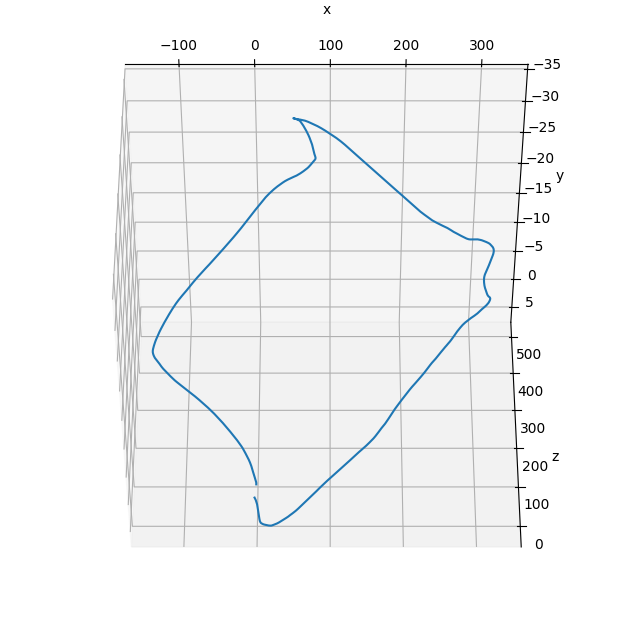

In [ ]:
import matplotlib.pyplot as plt
poses = []

T0 = np.vstack([gt[0], [0,0,0,1]])
T0_inv = np.linalg.inv(T0)

for i in range(len(gt)):
    T = np.vstack([gt[i], [0,0,0,1]])

    T_rel = T0_inv @ T
    pos = T_rel[:3, 3]
    poses.append(pos)

poses = np.array(poses)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(poses[:,0], poses[:,1], poses[:,2])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.view_init(elev=-40, azim=270)
plt.show()

문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오.

다음 내용을 포함하시오. • 이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명 • 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명 • projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명

1. 이미지 좌표에서 검출된 차선은 실제로는 카메라에서 뻗어나가는 여러 광선들의 집합으로써 의미를 가진다. 위의 projection mqtrix 수식에서 λ는 해당 점의 깊이(depth)이며, 하나의 픽셀은 카메라 좌표계에서 하나의 광선(ray)에 해당하기 때문이다.


2. 도로가 평면이라고 가정하면, 차선은 해당 평면 위에 존재하는 직선으로 볼 수 있다. 이 경우 3차원 공간에서의 차선은 일정한 평면 위의 직선이며, 이를 이미지로 투영하면 원근 효과에 의해 직선의 기울기와 간격이 변하게 된다. 특히, 카메라로부터 멀어질수록(큰 Z 값) 차선 간 간격은 점점 좁아지며, 이는 원근 투영의 특성에 따른 결과이다. 또한, 실제 결과 이미지에서도 가까운 영역에서는 차선이 넓게 퍼져 보이고, 먼 영역에서는 점점 모이는 형태를 확인할 수 있다.

3. 차선의 기울기는 카메라의 각도와 초점거리가 결정하고, 소실점은  Z→∞ 극한을 projection matrix에 넣었을 때 카메라 내부 파라미터(f_x, f_y, c_x, c_y)가 결정한다, 즉, Projection matrix의 원근 나눗셈이 평행선을 소실점으로 수렴시키고, 소실점 위치는 내부 파라미터가, 차선 기울기는 외부 파라미터(카메라 자세)가 결정한다.

In [ ]:
import argparse
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2

def list_frames(data_root: Path) -> list[Path]:
    return sorted(data_root.glob("*.png"))

def get_trapezoid_mask(width: int, height: int, vp_y_rate=0.5, bottom_width_rate=0.9, top_width_rate=0.15):
    """
    소실점을 기준으로 도로 가능성이 높은 사다리꼴 마스크를 생성합니다.
    """
    mask = np.zeros((height, width), dtype=np.uint8)

    vp_y = int(height * vp_y_rate)  # 소실점 높이 (일반적으로 지평선 부근)

    # 사다리꼴 네 꼭짓점 정의
    p1 = [int(width * (0.5 - top_width_rate)), vp_y]
    p2 = [int(width * (0.5 + top_width_rate)), vp_y]
    p3 = [int(width * (0.5 + bottom_width_rate/2)), height]
    p4 = [int(width * (0.5 - bottom_width_rate/2)), height]

    pts = np.array([p1, p2, p3, p4], np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def accumulate_weighted_histogram(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """마스크 영역 내의 픽셀만 사용하여 히스토그램 생성"""
    pixels = img[mask > 0]
    counts = np.bincount(pixels.flatten(), minlength=256)
    return counts.astype(np.float64)

def classify_frame(img: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, prior_road: float) -> tuple[np.ndarray, np.ndarray]:
    """Return MAP mask and probability map for road class."""
    eps = 1e-10  # numerical stability
    log_p_road = np.log(road_p[img] + eps) + math.log(prior_road)
    log_p_bg = np.log(bg_p[img] + eps) + math.log(1 - prior_road)

    logit = log_p_road - log_p_bg
    prob = 1.0 / (1.0 + np.exp(-np.clip(logit, -15, 15)))
    mask = logit > 0
    return mask, prob

def run(
    data_root: Path,
    train_frames: int,
    save_frames: int,
    out_dir: Path,
    prior_road: float,
    alpha: float = 0.8,
    video_path: Path | None = None,
    video_fps: float = 10.0,
    vp_y_rate: float = 0.5,
    bottom_width_rate: float = 0.9,
    top_width_rate: float = 0.15,
    max_frames: int | None = None,
    gif_path: Path | None = None,
    gif_fps: float = 8.0,
):
    """
    alpha: 시계열 일관성 계수 (0.8이면 기존 지식 80%, 새 프레임 20% 반영)
    save_frames: -1 이면 모든 프레임 저장
    video_path: 지정 시 overlay 프레임을 영상으로 기록
    """
    frames = list_frames(data_root)
    if not frames:
        raise SystemExit(f"No PNG frames found in {data_root}")

    sample_img = np.array(Image.open(frames[0]), dtype=np.uint8)
    h, w = sample_img.shape

    # 1. 소실점 기반 마스크 생성
    road_mask = get_trapezoid_mask(w, h, vp_y_rate, bottom_width_rate, top_width_rate)
    bg_mask = 1 - road_mask  # 도로 외 영역은 배경으로 간주

    # 초기 확률 분포 설정 (Laplace smoothing)
    road_p_total = np.ones(256)
    bg_p_total = np.ones(256)

    out_dir.mkdir(parents=True, exist_ok=True)

    limit = len(frames) if max_frames is None else min(max_frames, len(frames))
    max_frames_eval = max(train_frames, limit if save_frames >= 0 else len(frames))
    frames_iter = frames[:max_frames_eval]

    writer = None
    if video_path is not None:
        suffix = video_path.suffix.lower()
        if suffix == ".mp4":
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        else:  # default to MJPG/AVI
            fourcc = cv2.VideoWriter_fourcc(*"MJPG")
        writer = cv2.VideoWriter(str(video_path), fourcc, video_fps, (w, h))

    gif_frames: list[Image.Image] = []

    for idx, path in enumerate(frames_iter):
        img = np.array(Image.open(path), dtype=np.uint8)

        # 2. 현재 프레임의 히스토그램 추출
        curr_road_counts = accumulate_weighted_histogram(img, road_mask)
        curr_bg_counts = accumulate_weighted_histogram(img, bg_mask)

        # 3. 시계열 일관성 적용 (이동 평균)
        if idx == 0:
            road_p_total = curr_road_counts + 1
            bg_p_total = curr_bg_counts + 1
        else:
            # alpha 가중치를 이용해 이전 분포와 현재 분포를 결합
            road_p_total = alpha * road_p_total + (1 - alpha) * (curr_road_counts + 1)
            bg_p_total = alpha * bg_p_total + (1 - alpha) * (curr_bg_counts + 1)

        # 정규화하여 확률 밀도 함수 생성
        road_p = road_p_total / road_p_total.sum()
        bg_p = bg_p_total / bg_p_total.sum()

        # 4. 분류 및 저장 (save_frames 이내 혹은 영상 필요 시)
        should_save = (save_frames < 0 or idx < save_frames or writer is not None) and (max_frames is None or idx < max_frames)
        if should_save:
            mask, prob = classify_frame(img, road_p, bg_p, prior_road)

            stem = path.stem
            Image.fromarray((mask.astype(np.uint8) * 255)).save(out_dir / f"mask_{stem}.png")
            prob_img = np.clip(prob * 255, 0, 255).astype(np.uint8)
            Image.fromarray(prob_img).save(out_dir / f"prob_{stem}.png")

            overlay = np.stack([img, img, img], axis=-1)
            overlay[mask, 0] = 255  # 도로 영역 빨간색 강조
            overlay[mask, 1:] = (overlay[mask, 1:] * 0.3).astype(np.uint8)
            Image.fromarray(overlay).save(out_dir / f"overlay_{stem}.png")

            if writer is not None:
                writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

            if gif_path is not None:
                gif_frames.append(Image.fromarray(overlay))

            print(f"Processed {stem} with temporal consistency")

    if writer is not None:
        writer.release()

    if gif_path is not None and gif_frames:
        duration_ms = int(1000 / gif_fps)
        gif_frames[0].save(
            gif_path,
            save_all=True,
            append_images=gif_frames[1:],
            duration=duration_ms,
            loop=0,
        )

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-root", type=Path, default=Path("/content/drive/MyDrive/dataset/sequences/09/image_0"))
    parser.add_argument("--train-frames", type=int, default=80)
    parser.add_argument("--save-frames", type=int, default=10, help="frames to save; -1 for all")
    parser.add_argument("--out-dir", type=Path, default=Path("outputs/bayes_road_advanced"))
    parser.add_argument("--prior-road", type=float, default=0.5)
    parser.add_argument("--alpha", type=float, default=0.85, help="Temporal consistency weight")
    parser.add_argument("--video-path", type=Path, default=None, help="if set, write overlay video here")
    parser.add_argument("--video-fps", type=float, default=10.0)
    parser.add_argument("--vp-y-rate", type=float, default=0.5, help="vanishing point height ratio")
    parser.add_argument("--bottom-width-rate", type=float, default=0.9)
    parser.add_argument("--top-width-rate", type=float, default=0.15)
    parser.add_argument("--max-frames", type=int, default=None, help="process at most this many frames (after sorting)")
    parser.add_argument("--gif-path", type=Path, default=None, help="optional GIF output of overlays")
    parser.add_argument("--gif-fps", type=float, default=8.0)
    args, unknown = parser.parse_known_args()
    run(
        args.data_root,
        args.train_frames,
        args.save_frames,
        args.out_dir,
        args.prior_road,
        args.alpha,
        args.video_path,
        args.video_fps,
        args.vp_y_rate,
        args.bottom_width_rate,
        args.top_width_rate,
        args.max_frames,
        args.gif_path,
        args.gif_fps,
    )

Processed 000000 with temporal consistency
Processed 000002 with temporal consistency
Processed 000003 with temporal consistency
Processed 000004 with temporal consistency
Processed 000005 with temporal consistency
Processed 000007 with temporal consistency
Processed 000008 with temporal consistency
Processed 000010 with temporal consistency
Processed 000011 with temporal consistency
Processed 000012 with temporal consistency


['prob_000008.png', 'mask_000002.png', 'overlay_000002.png', 'mask_000011.png', 'overlay_000010.png', 'prob_000007.png', 'mask_000012.png', 'mask_000010.png', 'mask_000003.png', 'mask_000007.png']


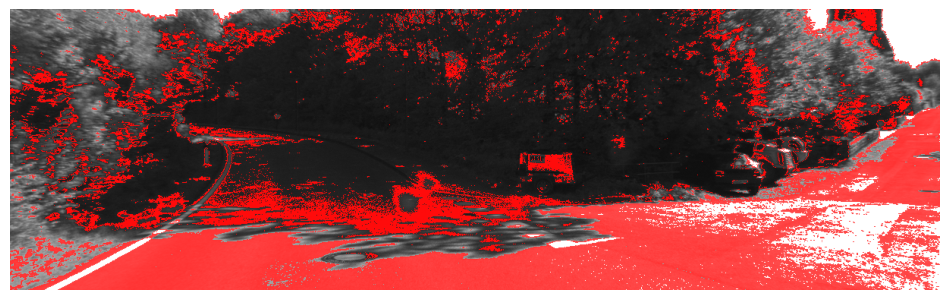

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

out_dir = "outputs/bayes_road_advanced"

print(os.listdir(out_dir)[:10])

img = Image.open(os.path.join(out_dir, "overlay_000000.png"))

plt.figure(figsize=(12,4))
plt.imshow(img)
plt.axis("off")
plt.show()

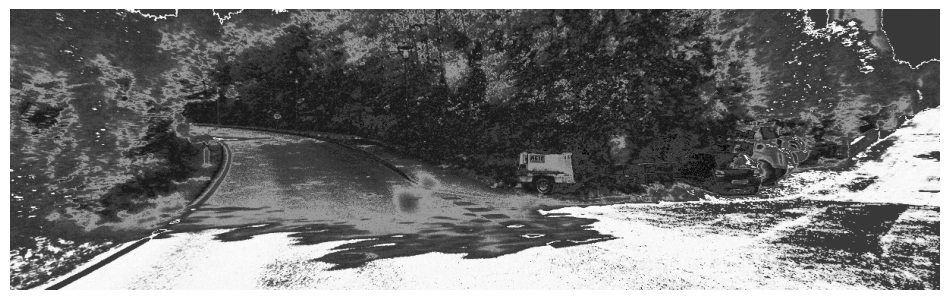

In [ ]:
prob = Image.open(os.path.join(out_dir, "prob_000000.png"))

plt.figure(figsize=(12,4))
plt.imshow(prob, cmap="gray")
plt.axis("off")
plt.show()

문제 5. 실패 구간 분석

차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오. • 해당 구간의 프레임 번호를 제시 • 궤적 상에서 해당 위치를 표시 • 왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것. • 조명 변화 또는 그림자 • 도로 질감 변화 • 차량의 회전 또는 경사 • ROI(사다리꼴 가정)의 한계

Frame 010-011
시퀀스 시작 직후 첫 커브. 학습 프레임이 10개밖에 안 쌓인 상태에서 회전이 시작되니까 road_p 히스토그램이 덜 수렴된 상태이다. ROI 사다리꼴도 소실점이 이미 이동했는데 고정값이라 도로 외 영역을 학습하게 되는 문제가 생긴다.


*   커브 구간은 도로 양옆에 나무가 밀집해있어서 그림자가 도로 위에 불규칙하게 드리워진다. 도로 픽셀 밝기가 정상 아스팔트가 아니라 그림자 영역으로 나타나면, 이 값이 배경의 밝기 분포와 겹쳐버려서 결과적으로 road_p 히스토그램이 그림자 픽셀을 도로로 학습하는 게 아니라, 배경과 구분이 안 되는 애매한 분포를 학습하여 overlay 이미지에서 도로 중앙이 검게 빠지고 나무 영역이 빨간색으로 잡히고 있다.
*   커브의 새로운 도로 질감이 road_p에 반영되는 속도가 너무 느려서, 커브 도로 픽셀이 배경으로 오분류되어 원래 도로의 색깔보다 어둡게 반영되고 있다,
*   poses 데이터에서 yaw 변화량을 분석했을 때 이 두 구간이 피크를 찍음. 차량이 커브를 돌면 카메라 광축 방향이 바뀌면서 이미지 내 소실점 위치가 좌우로 이동하고 있으나 코드는 소실점이 항상 이미지 수평 중앙(width * 0.5)에 고정돼있다고 가정하고 사다리꼴을 그린다. 소실점이 실제로 왼쪽으로 이동했는데 마스크는 중앙을 기준으로 잡고 있으니까, 마스크 오른쪽 절반이 실제 도로를 벗어나 풀밭이나 갓길을 포함하게 되는 문제가 생긴다.
*  Roi 사다리꼴의 한계로는, 커브 시에 소실점이 좌우로 이동하고 마스크 중심축이 틀어지는 문제와
오르막/내리막 시에 소실점이 위아래로 이동, vp_y_rate=0.5가 맞지 않는 문제가 있다. 또한,카메라 높이 변화 시 bottom_width_rate가 실제 도로 폭과 달라지는 한계가 있다,



문제 6. 딥리서치 등을 활용해 차선 검출을 위한 딥러닝 모델을 찾아 하나를 제안하고, 적용한 결과를 비교하여 보이시오.

UFLD v2 딥러닝 모델

기존 방식에서는 Frame 010-011에서 초반 히스토그램 미수렴+커브 소실점 이탈 문제와 Frame 222-230에서 급커브 시 ROI 마스크 완전 불일치 문제, 그리고 그림자 구간에서 조명 변화에 취약한 문제가 있었다.

하지만 위의 모델을 사용하면 사전학습 가중치로 즉시 추론이 가능하고, Hybrid Achor로 급커브시 직접 처리가 가능하다. 또한 그림자 구간에서는 특징 기반 분류로 조명 불변성 확보하여 이전의 문제점을 해결할 수 있다는 점에서 더 좋은 모델이라고 할 수 있다.
다만, 학습 데이터 도메인과 적용 환경(야간, 악천후 등)의 괴리가 존재할 경우 성능 저하 가능성이 여전히 남아있다.